### Creating Sample Datasets

In [2]:
import pandas as pd
import numpy as np

In [4]:
# Dataset 1: Employee Information
employees = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'department_id': [101, 102, 101, 103, 102],
    'salary': [50000, 60000, 55000, 65000, 58000]
})

# Dataset 2: Department Information
departments = pd.DataFrame({
    'dept_id': [101, 102, 103, 104],
    'dept_name': ['Sales', 'IT', 'HR', 'Finance'],
    'location': ['New York', 'San Francisco', 'Chicago', 'Boston']
})

# Dataset 3: Employee Projects
projects = pd.DataFrame({
    'emp_id': [1, 2, 2, 3, 5],
    'project_name': ['Project A', 'Project B', 'Project C', 'Project A', 'Project D'],
    'hours': [120, 150, 80, 100, 90]
})

print("Employees:")
print(employees)
print("\nDepartments:")
print(departments)
print("\nProjects:")
print(projects)

Employees:
   emp_id     name  department_id  salary
0       1    Alice            101   50000
1       2      Bob            102   60000
2       3  Charlie            101   55000
3       4    David            103   65000
4       5      Eve            102   58000

Departments:
   dept_id dept_name       location
0      101     Sales       New York
1      102        IT  San Francisco
2      103        HR        Chicago
3      104   Finance         Boston

Projects:
   emp_id project_name  hours
0       1    Project A    120
1       2    Project B    150
2       2    Project C     80
3       3    Project A    100
4       5    Project D     90


### Merging

#### pd.merge() - THE MAIN TOOL

### TYPES OF MERGES

#### A. INNER MERGE (Default)
Returns only rows that have matching values in both DataFrames.

In [5]:
# Inner merge: Only employees with matching departments
inner_merge = pd.merge(
    employees, 
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='inner'
)

print("INNER MERGE:")
inner_merge

INNER MERGE:


,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1,Alice,101,50000,101,Sales,New York
1,2,Bob,102,60000,102,IT,San Francisco
2,3,Charlie,101,55000,101,Sales,New York
3,4,David,103,65000,103,HR,Chicago
4,5,Eve,102,58000,102,IT,San Francisco


#### B. LEFT MERGE (LEFT OUTER JOIN)
Returns all rows from left DataFrame and matching rows from right DataFrame.

In [6]:
# Add employee with no department
employees_extended = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 5, 6],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
    'department_id': [101, 102, 101, 103, 102, 999],  # 999 doesn't exist
    'salary': [50000, 60000, 55000, 65000, 58000, 62000]
})

# Left merge: Keep all employees
left_merge = pd.merge(
    employees_extended,
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='left'
)

print("LEFT MERGE:")
left_merge

LEFT MERGE:


,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1,Alice,101,50000,101.0,Sales,New York
1,2,Bob,102,60000,102.0,IT,San Francisco
2,3,Charlie,101,55000,101.0,Sales,New York
3,4,David,103,65000,103.0,HR,Chicago
4,5,Eve,102,58000,102.0,IT,San Francisco
5,6,Frank,999,62000,NaN,NaN,NaN


In [7]:
inn_merge = pd.merge(
    employees_extended,
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='inner'
)
inn_merge

,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1,Alice,101,50000,101,Sales,New York
1,2,Bob,102,60000,102,IT,San Francisco
2,3,Charlie,101,55000,101,Sales,New York
3,4,David,103,65000,103,HR,Chicago
4,5,Eve,102,58000,102,IT,San Francisco


#### C. RIGHT MERGE (RIGHT OUTER JOIN)
Returns all rows from right DataFrame and matching rows from left DataFrame.

In [9]:
right_merge = pd.merge(
    employees,
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='right'
)

print("RIGHT MERGE:")
right_merge

RIGHT MERGE:


,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1.0,Alice,101.0,50000.0,101,Sales,New York
1,3.0,Charlie,101.0,55000.0,101,Sales,New York
2,2.0,Bob,102.0,60000.0,102,IT,San Francisco
3,5.0,Eve,102.0,58000.0,102,IT,San Francisco
4,4.0,David,103.0,65000.0,103,HR,Chicago
5,NaN,NaN,NaN,NaN,104,Finance,Boston


#### D. OUTER MERGE (FULL OUTER JOIN)
Returns all rows from both DataFrames, with NaN where there's no match.

In [8]:
# Outer merge: Keep all employees AND all departments
outer_merge = pd.merge(
    employees,
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='outer'
)

print("OUTER MERGE:")
outer_merge

OUTER MERGE:


,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1.0,Alice,101.0,50000.0,101,Sales,New York
1,3.0,Charlie,101.0,55000.0,101,Sales,New York
2,2.0,Bob,102.0,60000.0,102,IT,San Francisco
3,5.0,Eve,102.0,58000.0,102,IT,San Francisco
4,4.0,David,103.0,65000.0,103,HR,Chicago
5,NaN,NaN,NaN,NaN,104,Finance,Boston


#### 6. MERGING ON MULTIPLE COLUMNS

In [9]:
# Create data with composite keys
sales_data = pd.DataFrame({
    'region': ['North', 'North', 'South', 'South'],
    'quarter': ['Q1', 'Q2', 'Q1', 'Q2'],
    'sales': [100, 150, 120, 180]
})
sales_data

,region,quarter,sales
0,North,Q1,100
1,North,Q2,150
2,South,Q1,120
3,South,Q2,180


In [6]:

targets_data = pd.DataFrame({
    'region': ['North', 'North', 'South', 'South', 'East'],
    'quarter': ['Q1', 'Q2', 'Q1', 'Q2', 'Q1'],
    'target': [110, 160, 130, 190, 140]
})
targets_data

,region,quarter,target
0,North,Q1,110
1,North,Q2,160
2,South,Q1,130
3,South,Q2,190
4,East,Q1,140


In [11]:

# Merge on multiple columns
multi_merge = pd.merge(
    sales_data,
    targets_data,
    on=['region', 'quarter'],  # List of columns
    how='left'
)

print("Merge on multiple columns:")
multi_merge

Merge on multiple columns:


,region,quarter,sales,target
0,North,Q1,100,110
1,North,Q2,150,160
2,South,Q1,120,130
3,South,Q2,180,190


#### 7. HANDLING DUPLICATE COLUMN NAMES

In [17]:
# Create DataFrames with overlapping column names
df1 = pd.DataFrame({
    'key': ['A', 'B', 'C'],
    'value': [1, 2, 3],
    'score': [10, 20, 30]
})

df2 = pd.DataFrame({
    'key': ['A', 'B', 'D'],
    'value': [4, 5, 6],
    'score': [40, 50, 60]
})

In [18]:
df1

,key,value,score
0,A,1,10
1,B,2,20
2,C,3,30


In [19]:
df2

,key,value,score
0,A,4,40
1,B,5,50
2,D,6,60


In [59]:

# Merge with custom suffixes
merged_suffix = pd.merge(
    df1, df2,
    on='key',
    how='outer',
    suffixes=('_left', '_right')  # Custom suffixes for duplicate columns
)

print("Merge with custom suffixes:")
merged_suffix

Merge with custom suffixes:


,key,value_left,score_left,value_right,score_right
0,A,1.0,10.0,4.0,40.0
1,B,2.0,20.0,5.0,50.0
2,C,3.0,30.0,NaN,NaN
3,D,NaN,NaN,6.0,60.0


In [61]:
merged_suffix = pd.merge(
    df1, df2,
    on='key',
    how='outer',
    suffixes=(f'_df1', f'_df2')  # Custom suffixes for duplicate columns
)

print("Merge with custom suffixes:")
merged_suffix

Merge with custom suffixes:


,key,value_df1,score_df1,value_df2,score_df2
0,A,1.0,10.0,4.0,40.0
1,B,2.0,20.0,5.0,50.0
2,C,3.0,30.0,NaN,NaN
3,D,NaN,NaN,6.0,60.0


In [2]:
# Create DataFrames with indexes
emp_indexed = employees.set_index('emp_id')
proj_indexed = projects.set_index('emp_id')

NameError: name 'employees' is not defined

### DataFrame.join() METHOD
The .join() method is optimized for joining on indexes.

In [63]:
emp_indexed

,name,department_id,salary
emp_id,,,
1,Alice,101,50000
2,Bob,102,60000
3,Charlie,101,55000
4,David,103,65000
5,Eve,102,58000


In [1]:
proj_indexed

NameError: name 'proj_indexed' is not defined

In [24]:
# Join on index
joined = emp_indexed.join(proj_indexed, how='left', lsuffix='_emp', rsuffix='_proj')
print("\nJoined on index:")
joined


Joined on index:


,name,department_id,salary,project_name,hours
emp_id,,,,,
1,Alice,101,50000,Project A,120.0
2,Bob,102,60000,Project B,150.0
2,Bob,102,60000,Project C,80.0
3,Charlie,101,55000,Project A,100.0
4,David,103,65000,NaN,NaN
5,Eve,102,58000,Project D,90.0


### MERGE vs JOIN Comparison

In [26]:
# Using merge (explicit)
merge_result = pd.merge(
    emp_indexed,
    proj_indexed,
    left_index=True,
    right_index=True,
    how='left'
)
merge_result

,name,department_id,salary,project_name,hours
emp_id,,,,,
1,Alice,101,50000,Project A,120.0
2,Bob,102,60000,Project B,150.0
2,Bob,102,60000,Project C,80.0
3,Charlie,101,55000,Project A,100.0
4,David,103,65000,NaN,NaN
5,Eve,102,58000,Project D,90.0


In [27]:
# Using join (simpler syntax)
join_result = emp_indexed.join(
    proj_indexed, 
    how='left', 
    rsuffix='_proj'
)
join_result

,name,department_id,salary,project_name,hours
emp_id,,,,,
1,Alice,101,50000,Project A,120.0
2,Bob,102,60000,Project B,150.0
2,Bob,102,60000,Project C,80.0
3,Charlie,101,55000,Project A,100.0
4,David,103,65000,NaN,NaN
5,Eve,102,58000,Project D,90.0


In [28]:
print("Results are equivalent:")
print(merge_result.equals(join_result.drop(columns=[col for col in join_result.columns if '_proj' in col], errors='ignore')))

Results are equivalent:
True


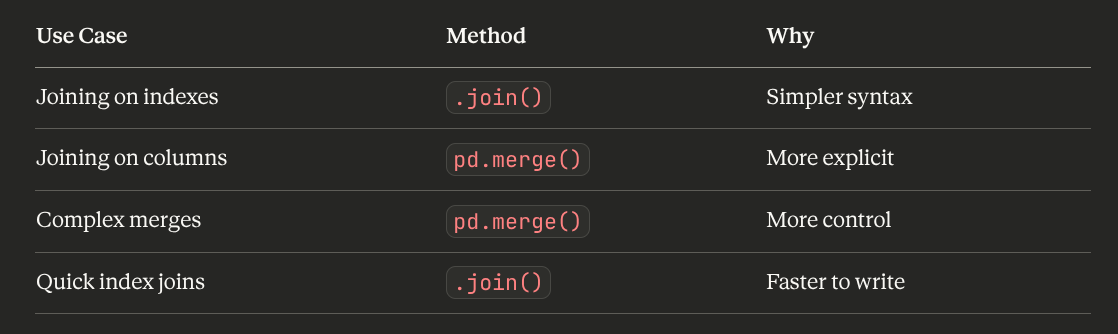

### INDICATOR PARAMETER
Track which DataFrame each row came from.

In [30]:
employees_extended

,emp_id,name,department_id,salary
0,1,Alice,101,50000
1,2,Bob,102,60000
2,3,Charlie,101,55000
3,4,David,103,65000
4,5,Eve,102,58000
5,6,Frank,999,62000


In [31]:
departments

,dept_id,dept_name,location
0,101,Sales,New York
1,102,IT,San Francisco
2,103,HR,Chicago
3,104,Finance,Boston


In [32]:
# Add indicator column
merge_indicator = pd.merge(
    employees_extended,
    departments,
    left_on='department_id',
    right_on='dept_id',
    how='outer',
    indicator=True  # Adds '_merge' column
)

print("Merge with indicator:")
merge_indicator

Merge with indicator:


,emp_id,name,department_id,salary,dept_id,dept_name,location,_merge
0,1.0,Alice,101.0,50000.0,101.0,Sales,New York,both
1,3.0,Charlie,101.0,55000.0,101.0,Sales,New York,both
2,2.0,Bob,102.0,60000.0,102.0,IT,San Francisco,both
3,5.0,Eve,102.0,58000.0,102.0,IT,San Francisco,both
4,4.0,David,103.0,65000.0,103.0,HR,Chicago,both
5,NaN,NaN,NaN,NaN,104.0,Finance,Boston,right_only
6,6.0,Frank,999.0,62000.0,NaN,NaN,NaN,left_only


### VALIDATING MERGES
Ensure merge relationships are correct:

In [33]:
# Validate one-to-one relationship
try:
    merge_validate = pd.merge(
        employees,
        departments,
        left_on='department_id',
        right_on='dept_id',
        how='inner',
        validate='one_to_one'  # Will raise error if not 1:1
    )
except pd.errors.MergeError as e:
    print(f"Validation Error: {e}")


Validation Error: Merge keys are not unique in left dataset; not a one-to-one merge
Duplicates in left:
  department_id
           101
           102 ...


In [34]:
# Validate one-to-many (correct for our data)
try:
    merge_validate = pd.merge(
        employees,
        departments,
        left_on='department_id',
        right_on='dept_id',
        how='inner',
        validate='many_to_one'  # Many employees to one department
    )
except pd.errors.MergeError as e:
    print(f"Validation Error: {e}")

In [35]:
merge_validate

,emp_id,name,department_id,salary,dept_id,dept_name,location
0,1,Alice,101,50000,101,Sales,New York
1,2,Bob,102,60000,102,IT,San Francisco
2,3,Charlie,101,55000,101,Sales,New York
3,4,David,103,65000,103,HR,Chicago
4,5,Eve,102,58000,102,IT,San Francisco


## CONCATENATION WITH pd.concat()
For stacking DataFrames vertically or horizontally:

In [46]:
# Create DataFrames for different time periods
q1_sales = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'q1_sales': [100, 150, 120]
})

q2_sales = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'q2_sales': [110, 160, 130]
})

q3_sales = pd.DataFrame({
    'product': ['A', 'B', 'D'],  # Note: D instead of C
    'q3_sales': [120, 170, 140]
})

In [47]:
# Concatenate horizontally (side by side)
horizontal_concat = pd.concat([q1_sales, q2_sales.drop('product', axis=1)], axis=1)
print("Horizontal concatenation:")
horizontal_concat

Horizontal concatenation:


,product,q1_sales,q2_sales
0,A,100,110
1,B,150,160
2,C,120,130


In [50]:
# Stack DataFrames vertically
sales_2023 = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=3),
    'sales': [100, 150, 120]
})

sales_2024 = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=3),
    'sales': [110, 160, 130]
})

vertical_concat = pd.concat([sales_2023, sales_2024], ignore_index=True)
print("Vertical concatenation:")
vertical_concat

Vertical concatenation:


,date,sales
0,2023-01-01,100
1,2023-01-02,150
2,2023-01-03,120
3,2024-01-01,110
4,2024-01-02,160
5,2024-01-03,130


#### Concatenation with Keys

In [54]:
concat_with_keys = pd.concat(
    [sales_2023, sales_2024],
    keys=['2023', '2024'],
    names=['Year', 'Row']
)
print("Concatenation with keys:")
concat_with_keys

Concatenation with keys:


date  sales
Year Row                  
2023 0   2023-01-01    100
     1   2023-01-02    150
     2   2023-01-03    120
2024 0   2024-01-01    110
     1   2024-01-02    160
     2   2024-01-03    130

In [55]:
# Customer data
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4, 5],
    'customer_name': ['John', 'Jane', 'Bob', 'Alice', 'Charlie'],
    'city': ['NYC', 'LA', 'Chicago', 'NYC', 'Boston'],
    'signup_date': pd.date_range('2023-01-01', periods=5)
})

# Order data
orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106],
    'customer_id': [1, 2, 1, 3, 2, 6],  # Note: customer 6 doesn't exist
    'order_amount': [250, 400, 300, 150, 500, 200],
    'order_date': pd.date_range('2023-02-01', periods=6)
})

# Product data
order_items = pd.DataFrame({
    'order_id': [101, 101, 102, 103, 104, 105],
    'product': ['Laptop', 'Mouse', 'Phone', 'Tablet', 'Keyboard', 'Monitor'],
    'quantity': [1, 2, 1, 1, 3, 2]
})

In [56]:
customers

,customer_id,customer_name,city,signup_date
0,1,John,NYC,2023-01-01
1,2,Jane,LA,2023-01-02
2,3,Bob,Chicago,2023-01-03
3,4,Alice,NYC,2023-01-04
4,5,Charlie,Boston,2023-01-05


In [57]:
orders

,order_id,customer_id,order_amount,order_date
0,101,1,250,2023-02-01
1,102,2,400,2023-02-02
2,103,1,300,2023-02-03
3,104,3,150,2023-02-04
4,105,2,500,2023-02-05
5,106,6,200,2023-02-06


In [58]:
order_items

,order_id,product,quantity
0,101,Laptop,1
1,101,Mouse,2
2,102,Phone,1
3,103,Tablet,1
4,104,Keyboard,3
5,105,Monitor,2
